# Generation 2: Poor Performance Results

This notebook analyzes the Generation 2 experiments that showed poor counterfactual generation performance, specifically:
- **SMOTE experiments**: Models trained with SMOTE oversampling (both base and gridsearched predictors)
- **Weighted experiments**: Models trained with class weights

These experiments demonstrated significantly lower validity and solved rates compared to baseline models.

------

In [1]:
# import
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [2]:
pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)


In [3]:
import os
from pathlib import Path
from dotenv import load_dotenv
load_dotenv()

ROOT_DIR = Path(os.getenv("PROJECT_ROOT"))

RESULTS_CSV_PATH = ROOT_DIR / "analysis" / "summary_data" / "gen_2_summary.csv"

print("root exists: ", ROOT_DIR.exists())
print("results is file: ", RESULTS_CSV_PATH.is_file())

root exists:  True
results is file:  True


In [4]:
# Add project root to path for imports
import sys
if str(ROOT_DIR) not in sys.path:
    sys.path.insert(0, str(ROOT_DIR))

In [5]:
df = pd.read_csv(RESULTS_CSV_PATH)

In [6]:
df.head(3)

,experiment,explainer_type,ml_model_type,use_permitted_range,total_cfs_requested,maxiterations,stopping_threshold,n_patients,total_cfs,valid_cfs,validity_%,solved_%,actionable_%,avg_nchanged_valid,avg_nchanged_all,avg_gower_all,min_gower_all,max_gower_all,low_gower_count_all,low_gower_<0.02_%_all,high_gower_count_all,high_gower_>0.35_%_all,gower_q25_all,gower_median_all,gower_q75_all,avg_gower_valid,min_gower_valid,max_gower_valid,low_gower_count_valid,low_gower_<0.02_%_valid,high_gower_count_valid,high_gower_>0.35_%_valid,avg_risk_before,avg_risk_after,min_risk_after,risk_reduction_%,total_gen_time_sec,avg_gen_time_sec,top_features,csv_path
0,RandomForest_thres0.5_2026-05-11,genetic,RandomForest,True,10,1000,0.5,9,89,28,31.5%,100.0%,89.9%,2.50,2.35,0.19,0.0002,0.4607,4,4.5%,11,12.4%,0.1183,0.1653,0.2505,0.19,0.0569,0.4607,0,0.0%,2,7.1%,0.2571,0.1194,0.000,70.1,86.48,9.61,bmi: 100% | alcfreq: 36% | slprl: 29% | ...,predictors_vs_threshold/SMOTE/base_predictors/...
1,RandomForest_thres0.9_2026-05-11,genetic,RandomForest,True,10,1000,0.9,9,56,23,41.1%,88.9%,89.3%,2.57,2.25,0.18,0.0001,0.4607,2,3.6%,3,5.4%,0.1217,0.1741,0.2503,0.21,0.0597,0.4607,0,0.0%,2,8.7%,0.2042,0.1016,0.000,71.9,144.35,16.04,bmi: 100% | alcfreq: 39% | dosprt: 39% | ...,predictors_vs_threshold/SMOTE/base_predictors/...
2,XGBoost_thres0.5_2026-05-11,genetic,XGBoost,True,10,1000,0.5,9,90,30,33.3%,55.6%,88.9%,2.83,2.41,0.20,0.0003,0.5678,5,5.6%,12,13.3%,0.1251,0.1728,0.2528,0.25,0.0177,0.5321,1,3.3%,7,23.3%,0.3452,0.1490,0.001,74.5,9.40,1.04,bmi: 100% | dosprt: 43% | alcfreq: 40% | ...,predictors_vs_threshold/SMOTE/base_predictors/...


## Filter for SMOTE and Weighted Experiments

We'll filter the data to include only the experiments from SMOTE and weighted folders.

In [7]:
# Filter for SMOTE and weighted experiments only
df_bad = df[df['csv_path'].str.contains('SMOTE|weighted', regex=True)].copy()
print(f"Total experiments: {len(df)}")
print(f"SMOTE + Weighted experiments: {len(df_bad)}")
df_bad

Total experiments: 17
SMOTE + Weighted experiments: 8


,experiment,explainer_type,ml_model_type,use_permitted_range,total_cfs_requested,maxiterations,stopping_threshold,n_patients,total_cfs,valid_cfs,validity_%,solved_%,actionable_%,avg_nchanged_valid,avg_nchanged_all,avg_gower_all,min_gower_all,max_gower_all,low_gower_count_all,low_gower_<0.02_%_all,high_gower_count_all,high_gower_>0.35_%_all,gower_q25_all,gower_median_all,gower_q75_all,avg_gower_valid,min_gower_valid,max_gower_valid,low_gower_count_valid,low_gower_<0.02_%_valid,high_gower_count_valid,high_gower_>0.35_%_valid,avg_risk_before,avg_risk_after,min_risk_after,risk_reduction_%,total_gen_time_sec,avg_gen_time_sec,top_features,csv_path
0,RandomForest_thres0.5_2026-05-11,genetic,RandomForest,True,10,1000,0.5,9,89,28,31.5%,100.0%,89.9%,2.50,2.35,0.19,0.0002,0.4607,4,4.5%,11,12.4%,0.1183,0.1653,0.2505,0.19,0.0569,0.4607,0,0.0%,2,7.1%,0.2571,0.1194,0.0000,70.1,86.48,9.61,bmi: 100% | alcfreq: 36% | slprl: 29% | ...,predictors_vs_threshold/SMOTE/base_predictors/...
1,RandomForest_thres0.9_2026-05-11,genetic,RandomForest,True,10,1000,0.9,9,56,23,41.1%,88.9%,89.3%,2.57,2.25,0.18,0.0001,0.4607,2,3.6%,3,5.4%,0.1217,0.1741,0.2503,0.21,0.0597,0.4607,0,0.0%,2,8.7%,0.2042,0.1016,0.0000,71.9,144.35,16.04,bmi: 100% | alcfreq: 39% | dosprt: 39% | ...,predictors_vs_threshold/SMOTE/base_predictors/...
2,XGBoost_thres0.5_2026-05-11,genetic,XGBoost,True,10,1000,0.5,9,90,30,33.3%,55.6%,88.9%,2.83,2.41,0.20,0.0003,0.5678,5,5.6%,12,13.3%,0.1251,0.1728,0.2528,0.25,0.0177,0.5321,1,3.3%,7,23.3%,0.3452,0.1490,0.0010,74.5,9.40,1.04,bmi: 100% | dosprt: 43% | alcfreq: 40% | ...,predictors_vs_threshold/SMOTE/base_predictors/...
3,XGBoost_thres0.9_2026-05-11,genetic,XGBoost,True,10,1000,0.9,9,50,21,42.0%,66.7%,94.0%,2.86,2.42,0.19,0.0497,0.3796,0,0.0%,5,10.0%,0.1250,0.1581,0.2503,0.21,0.1000,0.3796,0,0.0%,2,9.5%,0.2807,0.1044,0.0021,77.9,9.55,1.06,bmi: 100% | alcfreq: 52% | dosprt: 48% | ...,predictors_vs_threshold/SMOTE/base_predictors/...
4,RandomForest_thres0.5_2026-05-11,genetic,RandomForest,True,10,1000,0.5,9,89,8,9.0%,33.3%,88.8%,3.38,2.39,0.18,0.0002,0.4607,5,5.6%,9,10.1%,0.1122,0.1584,0.2507,0.21,0.1201,0.3147,0,0.0%,0,0.0%,0.3461,0.1402,0.0826,65.7,140.61,15.62,bmi: 100% | alcfreq: 50% | slprl: 50% | ...,predictors_vs_threshold/SMOTE/gridsearched_pre...
5,XGBoost_thres0.5_2026-05-11,genetic,XGBoost,True,10,1000,0.5,9,87,17,19.5%,55.6%,88.5%,3.24,2.37,0.17,0.0001,0.4607,4,4.6%,9,10.3%,0.1103,0.1475,0.2374,0.21,0.0492,0.3892,0,0.0%,2,11.8%,0.3933,0.1828,0.0933,63.3,100.08,11.12,bmi: 100% | alcfreq: 59% | dosprt: 53% | ...,predictors_vs_threshold/SMOTE/gridsearched_pre...
12,RandomForest_thres0.5_2026-05-11,genetic,RandomForest,True,10,1000,0.5,9,90,0,0.0%,0.0%,88.9%,NaN,2.44,0.21,0.0004,0.4607,4,4.4%,13,14.4%,0.1251,0.1987,0.2896,NaN,NaN,NaN,0,0.0%,0,0.0%,0.4465,NaN,NaN,NaN,25.59,2.84,NaN,predictors_vs_threshold/weighted/RandomForest_...
13,XGBoost_thres0.5_2026-05-11,genetic,XGBoost,True,10,1000,0.5,9,90,21,23.3%,55.6%,88.9%,3.19,2.60,0.21,0.0004,0.4607,3,3.3%,14,15.6%,0.1252,0.1870,0.2946,0.25,0.0944,0.4607,0,0.0%,5,23.8%,0.4771,0.2274,0.1064,60.3,8.96,1.00,bmi: 100% | dosprt: 67% | slprl: 52% | a...,predictors_vs_threshold/weighted/XGBoost_thres...


In [8]:
# Create a category column for better grouping
df_bad['category'] = df_bad['csv_path'].apply(
    lambda x: 'SMOTE (Base)' if 'SMOTE/base_predictors' in x
              else 'SMOTE (Gridsearched)' if 'SMOTE/gridsearched' in x
              else 'Weighted'
)

# Add model abbreviation
df_bad['model_abbr'] = df_bad['ml_model_type'].str[:3]

df_bad[['experiment', 'category', 'ml_model_type', 'stopping_threshold', 'validity_%', 'solved_%']]

,experiment,category,ml_model_type,stopping_threshold,validity_%,solved_%
0,RandomForest_thres0.5_2026-05-11,SMOTE (Base),RandomForest,0.5,31.5%,100.0%
1,RandomForest_thres0.9_2026-05-11,SMOTE (Base),RandomForest,0.9,41.1%,88.9%
2,XGBoost_thres0.5_2026-05-11,SMOTE (Base),XGBoost,0.5,33.3%,55.6%
3,XGBoost_thres0.9_2026-05-11,SMOTE (Base),XGBoost,0.9,42.0%,66.7%
4,RandomForest_thres0.5_2026-05-11,SMOTE (Gridsearched),RandomForest,0.5,9.0%,33.3%
5,XGBoost_thres0.5_2026-05-11,SMOTE (Gridsearched),XGBoost,0.5,19.5%,55.6%
12,RandomForest_thres0.5_2026-05-11,Weighted,RandomForest,0.5,0.0%,0.0%
13,XGBoost_thres0.5_2026-05-11,Weighted,XGBoost,0.5,23.3%,55.6%


## Visualization

Comparing the poor-performing experiments across different categories and thresholds.

In [9]:
# Prepare data for visualization
df_bad["Validity_%"] = df_bad["validity_%"].str.rstrip('%').astype(float)
df_bad["Solved_%"] = df_bad["solved_%"].str.rstrip('%').astype(float)
df_bad["Actionable_%"] = df_bad["actionable_%"].str.rstrip('%').astype(float)
df_bad["Time"] = df_bad["total_gen_time_sec"]

# Create labels
df_bad["Category"] = df_bad["category"]
df_bad["Model"] = df_bad["ml_model_type"]
df_bad["Threshold"] = df_bad["stopping_threshold"]

# Number of changes metrics
df_bad["Avg_NChanged_All"] = df_bad["avg_nchanged_all"]
df_bad["Avg_NChanged_Valid"] = df_bad["avg_nchanged_valid"]

# Gower distance metrics - ALL CFs
# Note: Column names now include threshold values (e.g., "low_gower_<0.02_%_all")
df_bad["Avg_Gower_All"] = df_bad["avg_gower_all"]
low_col_all = [c for c in df_bad.columns if c.startswith("low_gower_<") and c.endswith("_%_all")][0]
high_col_all = [c for c in df_bad.columns if c.startswith("high_gower_>") and c.endswith("_%_all")][0]
df_bad["Low_Gower_%_All"] = df_bad[low_col_all].str.rstrip('%').astype(float)
df_bad["High_Gower_%_All"] = df_bad[high_col_all].str.rstrip('%').astype(float)
df_bad["Median_Gower_All"] = df_bad["gower_median_all"]

# Gower distance metrics - VALID CFs only
df_bad["Avg_Gower_Valid"] = df_bad["avg_gower_valid"]
low_col_valid = [c for c in df_bad.columns if c.startswith("low_gower_<") and c.endswith("_%_valid")][0]
high_col_valid = [c for c in df_bad.columns if c.startswith("high_gower_>") and c.endswith("_%_valid")][0]
df_bad["Low_Gower_%_Valid"] = df_bad[low_col_valid].str.rstrip('%').astype(float)
df_bad["High_Gower_%_Valid"] = df_bad[high_col_valid].str.rstrip('%').astype(float)
df_bad["Min_Gower_Valid"] = df_bad["min_gower_valid"]

# Add risk metrics for additional analysis (only for experiments with valid CFs)
df_bad["Risk_Before"] = df_bad["avg_risk_before"] * 100  # Convert to percentage
df_bad["Risk_After"] = df_bad["avg_risk_after"] * 100    # Convert to percentage
df_bad["Risk_Reduction_%"] = df_bad["risk_reduction_%"]


# Display summary
df_bad[["Category", "Model", "Threshold", "Validity_%", "Solved_%", "Time", "Avg_Gower_All", "Avg_Gower_Valid"]].sort_values(['Category', 'Model', 'Threshold'])

,Category,Model,Threshold,Validity_%,Solved_%,Time,Avg_Gower_All,Avg_Gower_Valid
0,SMOTE (Base),RandomForest,0.5,31.5,100.0,86.48,0.19,0.19
1,SMOTE (Base),RandomForest,0.9,41.1,88.9,144.35,0.18,0.21
2,SMOTE (Base),XGBoost,0.5,33.3,55.6,9.40,0.20,0.25
3,SMOTE (Base),XGBoost,0.9,42.0,66.7,9.55,0.19,0.21
4,SMOTE (Gridsearched),RandomForest,0.5,9.0,33.3,140.61,0.18,0.21
5,SMOTE (Gridsearched),XGBoost,0.5,19.5,55.6,100.08,0.17,0.21
12,Weighted,RandomForest,0.5,0.0,0.0,25.59,0.21,NaN
13,Weighted,XGBoost,0.5,23.3,55.6,8.96,0.21,0.25


## FacetGrid: Multi-Metric Comparison

Using FacetGrid to show all metrics in a compact layout, comparing across training methods.

### Prepare Data for FacetGrid

In [10]:
# Reshape data for performance metrics (Row 1)
df_performance = df_bad.melt(
    id_vars=["Category", "Model", "Threshold"],
    value_vars=["Validity_%", "Solved_%", "Time", "Avg_NChanged_All"],
    var_name="Metric",
    value_name="Value"
)

# Reshape data for risk metrics (Row 2)
df_risk = df_bad.melt(
    id_vars=["Category", "Model", "Threshold"],
    value_vars=["Risk_Before", "Risk_After", "Risk_Reduction_%", "Avg_NChanged_Valid"],
    var_name="Metric",
    value_name="Value"
)

# Reshape data for Gower ALL metrics (Row 3)
df_gower_all = df_bad.melt(
    id_vars=["Category", "Model", "Threshold"],
    value_vars=["Avg_Gower_All", "Low_Gower_%_All", "High_Gower_%_All", "Median_Gower_All"],
    var_name="Metric",
    value_name="Value"
)

# Reshape data for Gower VALID metrics (Row 4)
df_gower_valid = df_bad.melt(
    id_vars=["Category", "Model", "Threshold"],
    value_vars=["Avg_Gower_Valid", "Low_Gower_%_Valid", "High_Gower_%_Valid", "Min_Gower_Valid"],
    var_name="Metric",
    value_name="Value"
)

print("Performance metrics shape:", df_performance.shape)
print("Risk metrics shape:", df_risk.shape)
print("Gower ALL metrics shape:", df_gower_all.shape)
print("Gower VALID metrics shape:", df_gower_valid.shape)

Performance metrics shape: (32, 5)
Risk metrics shape: (32, 5)
Gower ALL metrics shape: (32, 5)
Gower VALID metrics shape: (32, 5)


### English Version - Combined Plot

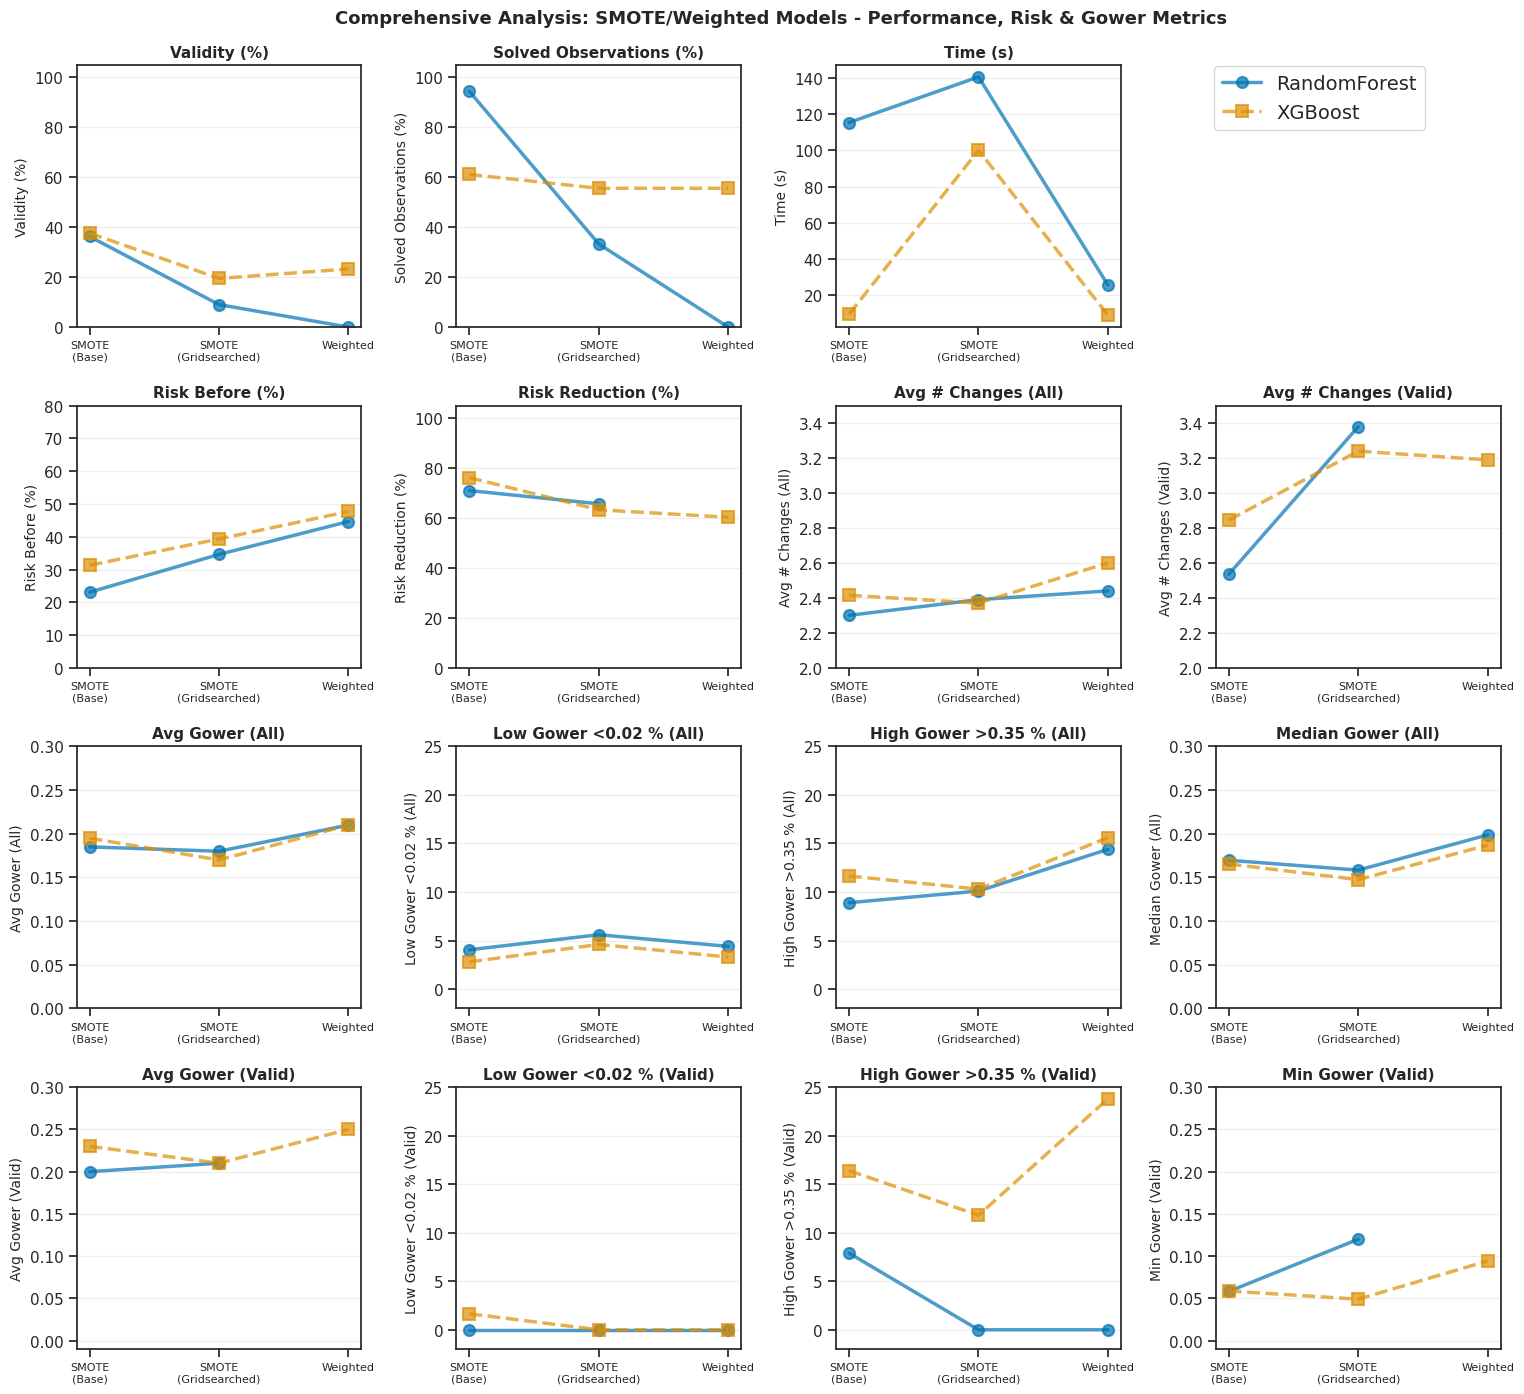

In [12]:
# English version - Using viz module
from analysis.viz import create_comprehensive_plot_by_category, prepare_plot_data

# Prepare data
df_dict = prepare_plot_data(df_bad)

# Category info
category_info = {
    'order': ['SMOTE (Base)', 'SMOTE (Gridsearched)', 'Weighted'],
    'labels': {
        'SMOTE (Base)': 'SMOTE\n(Base)',
        'SMOTE (Gridsearched)': 'SMOTE\n(Gridsearched)',
        'Weighted': 'Weighted'
    },
    'numeric': {
        'SMOTE (Base)': 0,
        'SMOTE (Gridsearched)': 1,
        'Weighted': 2
    }
}

# Create plot with title
create_comprehensive_plot_by_category(
    df_dict,
    category_info,
    language='en',
    figsize=(16, 14),
    title="Comprehensive Analysis: SMOTE/Weighted Models - Performance, Risk & Gower Metrics"
);